# Analytical Solutions of the RO Model and Comparison with Numerical Solutions

This tutorial illustrates how to use the pyCRO to solve the RO model analytically. In Appendix B of CRO paper (Kim et al. in preparation), we derive the analytical solutions for the **linear RO model with additive white noise**. The system is:

$$
\frac{dT}{dt} = RT + F_1 h + \sigma_T w_T
$$

$$
\frac{dh}{dt} = -F_2 T - \varepsilon h + \sigma_h w_h
$$

Because the system is linear with additive stochastic forcing, it can be solved using standard methods for linear stochastic differential equations.

## Analytical Trajectories of T and h

$$
T(t) =
e^{\lambda_r t}
\Big[
T_0 \Big(
\cos(\omega t)
+ \frac{R + \varepsilon}{2\omega}\sin(\omega t)
\Big)
+ h_0 \frac{F_1}{\omega}\sin(\omega t)
+ \mathcal{I}_T(t)
\Big]
$$

$$
h(t) =
e^{\lambda_r t}
\Big[
h_0 \Big(
\cos(\omega t)
- \frac{R + \varepsilon}{2\omega}\sin(\omega t)
\Big)
- T_0 \frac{F_2}{\omega}\sin(\omega t)
+ \mathcal{I}_h(t)
\Big]
$$


where


$$
\mathcal{I}_T(t) =
\int_0^t e^{-\lambda_r \tau}
\Big[
\sigma_T w_T(\tau)\cos(\omega(t-\tau))
+ \sigma_T w_T(\tau)\frac{R+\varepsilon}{2\omega}\sin(\omega(t-\tau))
+ \sigma_h w_h(\tau)\frac{F_1}{\omega}\sin(\omega(t-\tau))
\Big] d\tau
$$

$$
\mathcal{I}_h(t) =
\int_0^t e^{-\lambda_r \tau}
\Big[
\sigma_h w_h(\tau)\cos(\omega(t-\tau))
- \sigma_h w_h(\tau)\frac{R+\varepsilon}{2\omega}\sin(\omega(t-\tau))
- \sigma_T w_T(\tau)\frac{F_2}{\omega}\sin(\omega(t-\tau))
\Big] d\tau
$$

and

$$
\lambda_r = \frac{R - \varepsilon}{2}
$$

$$
\omega = \frac{\sqrt{4F_1 F_2 - (R + \varepsilon)^2}}{2}
$$

where:

- \($T_0, h_0$\): initial conditions  
- \($w_T, w_h$\): independent white noise processes  
- \($\sigma_T, \sigma_h$\): noise amplitudes  

## Analytical Ensemble Variance

$$
\langle T^2 \rangle =
\frac{
(F_1 F_2 - \varepsilon R + \varepsilon^2)\sigma_T^2
+ F_1^2 \sigma_h^2
}{
2(-R + \varepsilon)(F_1 F_2 - R\varepsilon)
}
$$

$$
\langle h^2 \rangle =
\frac{
F_2^2 \sigma_T^2
+ (F_1 F_2 - \varepsilon R + R^2)\sigma_h^2
}{
2(-R + \varepsilon)(F_1 F_2 - R\varepsilon)
}
$$


## Notes

- The system behaves as a damped stochastic oscillator when \(4F_1F_2 > (R+\varepsilon)^2\).
- These analytical expressions provide benchmarks for validating numerical RO solvers in **mCRO**.
- In practice, stochastic integrals are evaluated using ensemble simulations.

---

This notebook was contributed by [Soong-Ki Kim](https://csd.postech.ac.kr/professor).


## RO setup

In [ ]:
R=-0.05;       % dT/dt=R*T (month^-1)
F1=0.02;       % dT/dt=F1*h (K m^-1 month^-1)
F2=0.9;        % dh/dt=-F2*T (m K^-1 month^-1)
epsilon=0.03;  % dh/dt=-epsilon*h (month^-1)

% Nonlinear terms are omitted for the linear RO
b_T=0.0;
c_T=0.0;
d_T=0.0;
b_h=0.0;

% Additive white-noise parameters
sigma_T=0.2;
sigma_h=1.2;
B=0.0;
m_T=1.0;
m_h=1.0;
n_T=1;
n_h=1;
n_g=2;

par={R;F1;F2;epsilon;b_T;c_T;d_T;b_h; ...
     sigma_T;sigma_h;B;m_T;m_h;n_T;n_h;n_g};
IC=[1.0;0.0];  % Initial conditions for T and h
N=12*100;     % Simulation length in months (100 years)
NE=2;         % Number of ensemble members

NM="EH";                    % Numerical solver only: Euler-Heun (default)
dt=0.1;                     % Numerical time step in months
saveat=1.0;                 % Output interval in months
savemethod="sampling";      % "sampling" or "mean"
EF={0.0;0.0};               % Numerical solver only: external forcing
noise_custom=999;           % Reproducible random seed

## Analytic Solutions of Linear RO With White Noise


RO_solver_analytic returns the analytical trajectory solution for the linear, non-seasonal RO with additive white noise. 

Its calling structure is similar to RO_solver, except that the numerical integration method (NM) and external forcing (EF) are not accepted.


In [ ]:
[T_ref,h_ref,noise_ref]=RO_solver_analytic(par,IC,N,NE);
[T_ref,h_ref,noise_ref]=RO_solver_analytic(par,IC,N,NE,dt);
[T_ref,h_ref,noise_ref]=RO_solver_analytic(par,IC,N,NE,dt,saveat);
[T_ref,h_ref,noise_ref]=RO_solver_analytic(par,IC,N,NE,dt,saveat,savemethod);
[T_ref,h_ref,noise_ref]=RO_solver_analytic(par,IC,N,NE,dt,saveat,savemethod,noise_custom);

## Compare numerical and analytical trajectories


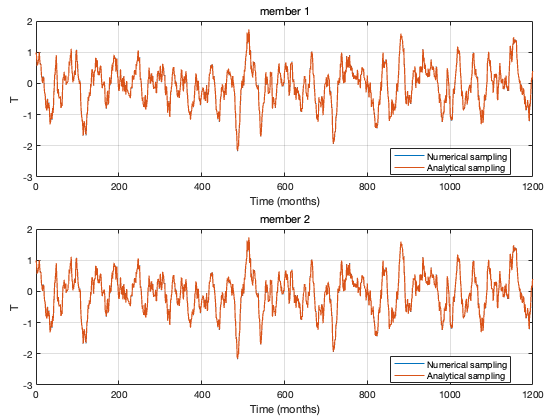

In [ ]:
% Example 3-3. Compare numerical and analytical solutions
NE=2;

[T_ro,h_ro,noise_ro]=RO_solver( ...
    par,IC,N,NE,NM,dt,saveat,savemethod,EF,noise_custom);

[T_ref,h_ref,noise_ref]=RO_solver_analytic( ...
    par,IC,N,NE,dt,saveat,savemethod,noise_custom);

time_axis=0:saveat:(round(N/saveat)-1)*saveat;

figure;
tiledlayout(2,1,'TileSpacing','compact','Padding','compact');

for i=1:NE
    nexttile
    plot(time_axis,T_ro(:,i),'LineWidth',1.2, ...
        'DisplayName','Numerical sampling')
    hold on
    plot(time_axis,T_ref(:,i),'LineWidth',1.2, ...
        'DisplayName','Analytical sampling')
    xlabel('Time (months)')
    ylabel('T')
    title(sprintf('member %d',i))
    legend('Location','best')
    grid on
end

## Analytic Amplitude of RO


RO_std_analytic returns the theoretical standard deviations of T and h for the linear-white-additive RO based on the supplied parameter set.


In [ ]:
[T_ref_std,h_ref_std]=RO_std_analytic(par);

RO_BWJ returns the BJ and Wyrtki indices as the real and imaginary parts of a complex value, respectively.


In [ ]:
BWJ=RO_BWJ(par);
BJ=real(BWJ);
Wyrtki=imag(BWJ);

## Compare numerical and analytical standard deviations


In [ ]:
% Example 3-4. Compare standard deviations of numerical and analytical solutions
[T_ref_std,h_ref_std]=RO_std_analytic(par);

% Use internally generated noise for the numerical ensemble comparison
noise_custom=[];
[T_ro,h_ro,noise_ro]=RO_solver( ...
    par,IC,N,NE,NM,dt,saveat,savemethod,EF,noise_custom);

T_ro_std=std(T_ro,0,1);
h_ro_std=std(h_ro,0,1);
T_ro_std_mean=mean(T_ro_std,'omitnan');
h_ro_std_mean=mean(h_ro_std,'omitnan');

fprintf('Standard deviations for T (analytical):\n');
disp(T_ref_std)
fprintf('Standard deviations for T (ensemble mean for numerical solutions):\n');
disp(T_ro_std_mean)
fprintf('Standard deviations for h (analytical):\n');
disp(h_ref_std)
fprintf('Standard deviations for h (ensemble mean for numerical solutions):\n');
disp(h_ro_std_mean)

Standard deviations for T (analytical):


    0.6679



Standard deviations for T (ensemble mean for numerical solutions):


    0.6520



Standard deviations for h (analytical):


    4.5319



Standard deviations for h (ensemble mean for numerical solutions):


    4.6443



BJ index: -0.040 [1/month]


Wyrtki index: 0.134 [1/month]. This corresponds to a periodicity of 46.963 months.
